# Entrenament models per predir PCC o MACA (Versió 3 - Ultra Precisió i Mètriques Realistes)

Aquest notebook està dissenyat per dur a terme el procés d'entrenament jeràrquic del model de predicció de malalts crònics complexos (PCC o MACA) seguint la metodologia següent:
1. **Nested Cross-Validation (Nested CV)**: S'avalua la capacitat de generalització del sistema complet (Stage 1 + Stage 2) de forma realista i sense biaix. Es cerca la millor combinació de paràmetres en un bucle intern per a cada fold exterior per evitar el "data leakage".
2. **Optimització de paràmetres finals**: S'executa un `GridSearchCV` sobre la totalitat del dataset per trobar els millors hiperparàmetres absoluts.
3. **Entrenament del model final**: Es reentrenen ambdós models utilitzant el 100% de les dades i es desen en format `joblib` per al seu ús en producció.

In [1]:
import os
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    precision_recall_fscore_support, 
    precision_recall_curve, 
    auc,
    fbeta_score,
    make_scorer,
    recall_score,
    brier_score_loss
)
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = "../data/processed/dataset_final_pcc.csv"
MODEL_S1_PATH = "models/model_stage1_v3.joblib"
MODEL_S2_PATH = "models/model_stage2_v3.joblib"
RANDOM_STATE = 42

print("--- Iniciant entrenament jeràrquic V3 (Ultra Precisió) ---")

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"ERROR: No trobo {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(f"Dataset carregat: {df.shape[0]} pacients, {df.shape[1]} columnes.")

--- Iniciant entrenament jeràrquic V3 (Ultra Precisió) ---
Dataset carregat: 37902 pacients, 122 columnes.


In [3]:
drop_cols = ["id_pacient", "target", "cronic"]
X_all = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

# Separem les columnes per a processar-les diferent
num_cols = X_all.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_all.select_dtypes(include=["object", "category"]).columns.tolist()

# Preprocessador per tractar les columnes numèriques i categòriques
preprocessor = ColumnTransformer(
    transformers=[
        # Imputem la mediana i escalem les columnes numèriques
        ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_cols),
        # Imputem la moda i convertim en one-hot
        ("cat", Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
    ]
)

In [4]:
# Mètric global per a la validació encreuada exterior
y_target = df["target"].values

outer_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

# Arrays per desar les prediccions i probabilitats de test de cada fold (Out-of-Fold)
oof_preds = np.zeros(len(df))
oof_probs = np.zeros((len(df), 3)) # 3 classes: NO, PCC, MACA

print("--- Iniciant Bucle de Nested Cross-Validation (Mètriques Realistes) ---")

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_all, y_target)):
    print(f"\n Processant fold exterior {fold + 1}...")
    
    # Partició de dades exterior
    X_train_f, X_test_f = X_all.iloc[train_idx], X_all.iloc[test_idx]
    y_train_f, y_test_f = y_target[train_idx], y_target[test_idx]
    
    # ----------------------------------------------------
    # ESTAT 1: CRÒNIC vs NO
    # ----------------------------------------------------
    y1_train_f = (y_train_f > 0).astype(int)
    
    model1 = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1))
    ])
    
    model1_params = {
        "classifier__max_depth": [20, 30, 50],
        "classifier__min_samples_leaf": [1, 2, 5]
    }
    
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    
    grid_model1 = GridSearchCV(
        estimator=model1,
        param_grid=model1_params,
        cv=inner_cv,
        scoring=make_scorer(recall_score, pos_label=1),
        n_jobs=-1
    )
    
    grid_model1.fit(X_train_f, y1_train_f)
    best_model1 = grid_model1.best_estimator_
    print(f"  [Estat 1] Millors paràmetres: {grid_model1.best_params_}")
    
    # ----------------------------------------------------
    # ESTAT 2: PCC vs MACA
    # ----------------------------------------------------
    # Filtrem només els pacients crònics en la partició de train
    chronic_mask = (y_train_f > 0)
    X2_train_f = X_train_f[chronic_mask]
    y2_train_f = y_train_f[chronic_mask]
    
    base_model2 = HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_STATE)
    
    model2 = Pipeline(steps=[
        ("preprocessor", preprocessor),
        #("classifier", base_model2)
        ("classifier", CalibratedClassifierCV(estimator=base_model2, cv=3))
    ])
    
    # base_pipeline = Pipeline([
    #     ("preprocessor", preprocessor),
    #     ("classifier", base_model2)
    # ])

    # model2 = CalibratedClassifierCV(
    #     estimator=base_pipeline,
    #     cv=3
    # )

    model2_params = {
        "classifier__estimator__max_depth": [5, 10, 15],
        "classifier__estimator__learning_rate": [0.01, 0.05, 0.1]
    }
    
    grid_model2 = GridSearchCV(
        estimator=model2,
        param_grid=model2_params,
        cv=inner_cv,
        scoring=make_scorer(recall_score, pos_label=2),
        n_jobs=-1
    )
    
    grid_model2.fit(X2_train_f, y2_train_f)
    best_model2 = grid_model2.best_estimator_
    print(f"  [Estat 2] Millors paràmetres: {grid_model2.best_params_}")
    
    # ----------------------------------------------------
    # AVALUACIÓ JERÀRQUICA OOF (OUT-OF-FOLD)
    # ----------------------------------------------------
    p_chronic = best_model1.predict_proba(X_test_f)[:, 1]
    p_no = 1.0 - p_chronic
    
    probs_s2 = best_model2.predict_proba(X_test_f) # classes [1, 2]
    p_pcc_given_chronic = probs_s2[:, 0]
    p_maca_given_chronic = probs_s2[:, 1]
    
    p_pcc = p_chronic * p_pcc_given_chronic
    p_maca = p_chronic * p_maca_given_chronic
    
    oof_probs[test_idx] = np.column_stack([p_no, p_pcc, p_maca])
    
    y_pred_fold = np.zeros_like(p_chronic, dtype=int)
    
    chronic_indices = np.where(p_chronic >= 0.55)[0]
    if len(chronic_indices) > 0:
        maca_mask = (p_maca_given_chronic[chronic_indices] >= 0.40)
        y_pred_fold[chronic_indices] = np.where(maca_mask, 2, 1)
        
    oof_preds[test_idx] = y_pred_fold

print("\n--- Bucle de Nested CV finalitzat correctament ---")

--- Iniciant Bucle de Nested Cross-Validation (Mètriques Realistes) ---

 Processant fold exterior 1...
  [Estat 1] Millors paràmetres: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 5}
  [Estat 2] Millors paràmetres: {'classifier__estimator__learning_rate': 0.01, 'classifier__estimator__max_depth': 15}

 Processant fold exterior 2...
  [Estat 1] Millors paràmetres: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 5}
  [Estat 2] Millors paràmetres: {'classifier__estimator__learning_rate': 0.01, 'classifier__estimator__max_depth': 15}

 Processant fold exterior 3...
  [Estat 1] Millors paràmetres: {'classifier__max_depth': 30, 'classifier__min_samples_leaf': 5}
  [Estat 2] Millors paràmetres: {'classifier__estimator__learning_rate': 0.01, 'classifier__estimator__max_depth': 15}

 Processant fold exterior 4...
  [Estat 1] Millors paràmetres: {'classifier__max_depth': 50, 'classifier__min_samples_leaf': 5}
  [Estat 2] Millors paràmetres: {'classifier__estimator

In [5]:
target_names = ["NO", "PCC", "MACA"]

print("\n==================================================")
print("AVALUACIÓ REALISTA (NESTED CROSS-VALIDATION OOF)")
print("==================================================")

prec, rec, f1, sup = precision_recall_fscore_support(y_target, oof_preds, average=None)
f2_scores = fbeta_score(y_target, oof_preds, beta=2, average=None)

pr_aucs = []
y_true_bin = pd.get_dummies(y_target).reindex(columns=[0, 1, 2], fill_value=0).values
for i in range(3):
    precision_curve, recall_curve, _ = precision_recall_curve(y_true_bin[:, i], oof_probs[:, i])
    pr_aucs.append(auc(recall_curve, precision_curve))

brier_scores = []
for i in range(3):
    brier_scores.append(brier_score_loss(y_true_bin[:, i], oof_probs[:, i]))

df_metrics = pd.DataFrame({
    "Precisió": prec,
    "Recall": rec,
    "F1-Score": f1,
    "F2-Score": f2_scores,
    "PR-AUC": pr_aucs,
    "Brier Score (Calibratge)": brier_scores,
    "Suport": sup
}, index=target_names)

print("\n1. MÈTRIQUES PER CLASSE:")
print(df_metrics.round(4))

macro_prec = np.mean(prec)
macro_rec = np.mean(rec)
macro_f1 = np.mean(f1)
macro_f2 = np.mean(f2_scores)

print("\n----------------------------------------")
print("2. MITJANES GENERALS (MACRO AVG):")
print("----------------------------------------")
print(f"Macro avg Precision: {macro_prec:.4f}")
print(f"Macro avg Recall   : {macro_rec:.4f}")
print(f"Macro avg F1-Score : {macro_f1:.4f}")
print(f"Macro avg F2-Score : {macro_f2:.4f}")

print("\n----------------------------------------")
print("3. MATRIU DE CONFUSIÓ (ABSOLUTA):")
print("----------------------------------------")
cm = confusion_matrix(y_target, oof_preds)
df_cm = pd.DataFrame(cm, index=target_names, columns=["Pred_NO", "Pred_PCC", "Pred_MACA"])
print(df_cm)

print("\n----------------------------------------")
print("4. MATRIU DE CONFUSIÓ NORMALITZADA (% SENSIVILITAT):")
print("----------------------------------------")
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
df_cm_norm = pd.DataFrame(cm_norm, index=target_names, columns=["Pred_NO", "Pred_PCC", "Pred_MACA"])
print(df_cm_norm.apply(lambda x: x.map(lambda y: f"{y:.2f} %")))


AVALUACIÓ REALISTA (NESTED CROSS-VALIDATION OOF)

1. MÈTRIQUES PER CLASSE:
      Precisió  Recall  F1-Score  F2-Score  PR-AUC  Brier Score (Calibratge)  \
NO      0.9315  0.8856    0.9080    0.8944  0.9735                    0.1097   
PCC     0.5922  0.6979    0.6407    0.6739  0.6920                    0.1097   
MACA    0.6098  0.6813    0.6436    0.6657  0.6798                    0.0186   

      Suport  
NO     29325  
PCC     7187  
MACA    1390  

----------------------------------------
2. MITJANES GENERALS (MACRO AVG):
----------------------------------------
Macro avg Precision: 0.7112
Macro avg Recall   : 0.7549
Macro avg F1-Score : 0.7308
Macro avg F2-Score : 0.7447

----------------------------------------
3. MATRIU DE CONFUSIÓ (ABSOLUTA):
----------------------------------------
      Pred_NO  Pred_PCC  Pred_MACA
NO      25970      3126        229
PCC      1794      5016        377
MACA      115       328        947

----------------------------------------
4. MATRIU DE CO

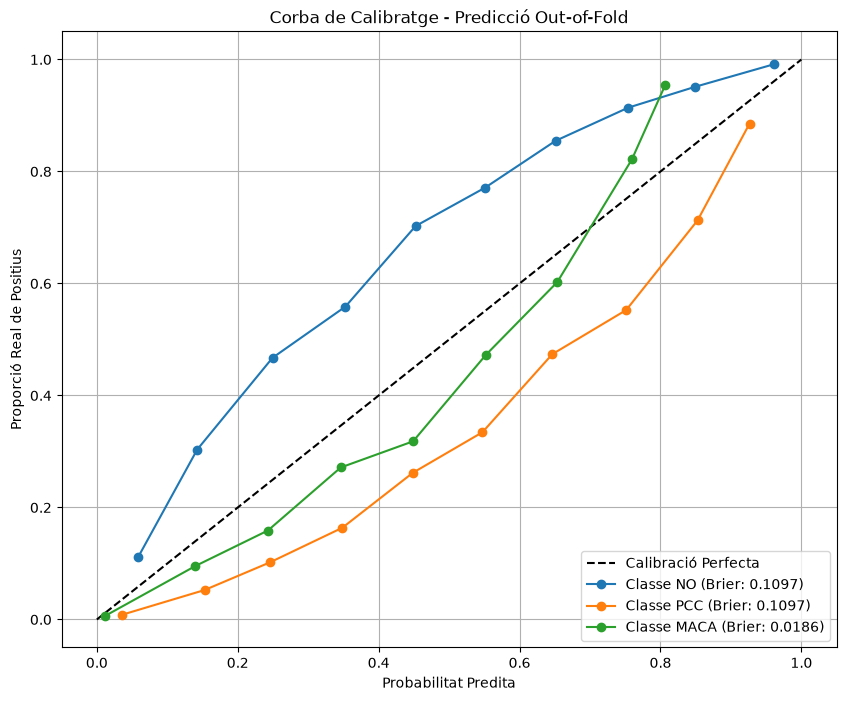

In [6]:
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], "k--", label="Calibració Perfecta")

for i, name in enumerate(target_names):
    prob_true, prob_pred = calibration_curve(y_true_bin[:, i], oof_probs[:, i], n_bins=10)
    plt.plot(prob_pred, prob_true, marker="o", label=f"Classe {name} (Brier: {brier_scores[i]:.4f})")

plt.xlabel("Probabilitat Predita")
plt.ylabel("Proporció Real de Positius")
plt.title("Corba de Calibratge - Predicció Out-of-Fold")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [7]:
print("\n--- Cerca de Paràmetres Finals per a l'Estat 1 (Random Forest) ---")
y1_all = (df["target"] > 0).astype(int)

model1_final_search = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1))
])

grid_search1 = GridSearchCV(
    estimator=model1_final_search,
    param_grid=model1_params,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring=make_scorer(recall_score, pos_label=1),
    n_jobs=-1
)

grid_search1.fit(X_all, y1_all)
best_params1 = grid_search1.best_params_
print("Millors paràmetres de l'Estat 1 (Random Forest):", best_params1)

print("\n--- Cerca de Paràmetres Finals per a l'Estat 2 (HistGradientBoosting) ---")
df_chronic = df[df["target"] > 0].copy()
X2_all = df_chronic.drop(columns=[c for c in drop_cols if c in df_chronic.columns]).copy()
y2_all = df_chronic["target"].copy()

base_model2_search = HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_STATE)

model2_final_search = Pipeline(steps=[
    ("preprocessor", preprocessor),
    #("classifier", base_model2_search)
    ("classifier", CalibratedClassifierCV(estimator=base_model2_search, cv=3))
])

grid_search2 = GridSearchCV(
    estimator=model2_final_search,
    param_grid=model2_params,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring=make_scorer(recall_score, pos_label=2),
    n_jobs=-1
)
grid_search2.fit(X2_all, y2_all)
best_params2 = grid_search2.best_params_
print("Millors paràmetres de l'Estat 2 (HistGradientBoosting):", best_params2)


--- Cerca de Paràmetres Finals per a l'Estat 1 (Random Forest) ---
Millors paràmetres de l'Estat 1 (Random Forest): {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 5}

--- Cerca de Paràmetres Finals per a l'Estat 2 (HistGradientBoosting) ---
Millors paràmetres de l'Estat 2 (HistGradientBoosting): {'classifier__estimator__learning_rate': 0.01, 'classifier__estimator__max_depth': 10}


In [8]:
print("\n--- Entrenant i desant els models finals de producció (100% de les dades) ---")

# 1. Estat 1 final
best_max_depth1 = best_params1["classifier__max_depth"]
best_min_samples_leaf1 = best_params1["classifier__min_samples_leaf"]

final_model1 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=best_max_depth1,
        min_samples_leaf=best_min_samples_leaf1,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])
final_model1.fit(X_all, y1_all)
print("Estat 1 entrenat correctament amb tot el dataset. ✅")

# 2. Estat 2 final
best_max_depth2 = best_params2["classifier__estimator__max_depth"]
best_lr2 = best_params2["classifier__estimator__learning_rate"]

final_base_model2 = HistGradientBoostingClassifier(
    max_iter=400,
    max_depth=best_max_depth2,
    learning_rate=best_lr2,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

final_model2 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", CalibratedClassifierCV(estimator=final_base_model2, cv=3))
])
final_model2.fit(X2_all, y2_all)
print("Estat 2 entrenat correctament amb tot el dataset de pacients crònics. ✅")

# 3. Desament dels pipelines a joblib
joblib.dump(final_model1, MODEL_S1_PATH)
joblib.dump(final_model2, MODEL_S2_PATH)
print(f"Model Stage 1 desat a: {MODEL_S1_PATH}")
print(f"Model Stage 2 desat a: {MODEL_S2_PATH}")

# 4. Generació de prediccions per a tot el dataset i desament al CSV
print("\n--- Generant prediccions per a tot el dataset final ---")
full_df = pd.read_csv(DATA_PATH)
drop_cols = ["id_pacient", "target", "cronic", "cronic_encoded", "sexe_encoded", "situacio_encoded", "edat_encoded"]
X_full = full_df.drop(columns=[c for c in drop_cols if c in full_df.columns], errors='ignore').copy()

probs_s1 = final_model1.predict_proba(X_full)
prob_chronic = probs_s1[:, 1]

probs_s2 = final_model2.predict_proba(X_full)
prob_pcc_cond = probs_s2[:, 0]
prob_maca_cond = probs_s2[:, 1]

prob_maca = prob_chronic * prob_maca_cond
prob_pcc = prob_chronic * prob_pcc_cond

pred_states = []
for p_ch, p_ma_cond in zip(prob_chronic, prob_maca_cond):
    if p_ch < 0.50:
        pred_states.append("NO")
    else: 
        if p_ma_cond >= 0.40:
            pred_states.append("MACA")
        else:
            pred_states.append("PCC")

full_df["prediccio_estat"] = pred_states
full_df["prob_maca"] = prob_maca
full_df["prob_pcc"] = prob_pcc

full_df.to_csv(DATA_PATH, index=False)
print(f"Prediccions afegides a {DATA_PATH} correctament!")
print("\n🎉 Tot el procés ha finalitzat correctament!")


--- Entrenant i desant els models finals de producció (100% de les dades) ---
Estat 1 entrenat correctament amb tot el dataset. ✅
Estat 2 entrenat correctament amb tot el dataset de pacients crònics. ✅
Model Stage 1 desat a: models/model_stage1_v3.joblib
Model Stage 2 desat a: models/model_stage2_v3.joblib

--- Generant prediccions per a tot el dataset final ---
Prediccions afegides a ../data/processed/dataset_final_pcc.csv correctament!

🎉 Tot el procés ha finalitzat correctament!
